In [26]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import(mean_absolute_error,mean_squared_error,r2_score)

In [3]:
df=pd.read_csv("/content/ev_car_India_dataset - ev_car_India_dataset.csv")

In [4]:
df.head()

,Brand,Model,Price,Range,Power,Battery
0,Maruti,SuzukieVitara,15.99,440,142.0,49.0
1,Tata,PunchEV,9.69,275,87.0,30.0
2,Mahindra,XEV9e,21.90,542,228.0,59.0
3,Mahindra,BE6,18.90,557,228.0,59.0
4,MG,WindsorEV,14.00,332,134.0,38.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Brand    26 non-null     object 
 1   Model    26 non-null     object 
 2   Price    26 non-null     float64
 3   Range    26 non-null     int64  
 4   Power    26 non-null     float64
 5   Battery  26 non-null     float64
dtypes: float64(3), int64(1), object(2)
memory usage: 1.3+ KB


In [6]:
df.shape

(26, 6)

In [7]:
df=df.dropna(subset=["Range","Price"])

In [10]:
df[["Range","Price"]].isnull().sum()

,0
Range,0
Price,0


In [11]:
X=df[["Range"]]
y=df["Price"]

In [12]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
model=LinearRegression()
model.fit(X_train,y_train)

LinearRegression()

In [14]:
print("Slope",model.coef_[0])
print("Intercept",model.intercept_)

Slope 0.14140952743197052
Intercept -34.39612070941648


In [15]:
y_pred=model.predict(X_test)

In [16]:
comparison=pd.DataFrame({
    "Actual Price":y_test.values,
    "Predicted Price":y_pred
})

In [17]:
print("\nActual vs Predicated:")
print(comparison.head(10))


Actual vs Predicated:
   Actual Price  Predicted Price
0         21.49        41.682205
1         17.29        31.783538
2         15.99        27.824071
3         72.50        33.904681
4          3.25        -9.649453
5          7.99         0.956261


Text(0.5, 1.0, 'Actual vs Predicted Price')

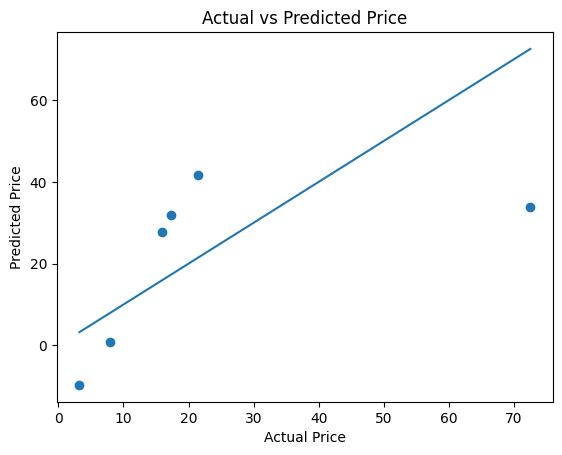

In [22]:
import matplotlib.pyplot as plt
plt.scatter(y_test,y_pred)
plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()]
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Price")

In [27]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred)
print("\nModel Evaluation")
print("-----------------")
print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R-squared:",r2)


Model Evaluation
-----------------
MAE: 17.50805429306669
MSE: 410.5501772136186
RMSE: 20.262037834670494
R-squared: 0.21789874655994523
